In [1]:
from functools import partial
from warnings import warn

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def prepare_matrix(x, h, s, l_y, l_z):
    A = np.ones((3 * len(s), len(x)))
    A[:, 0] = A[:, -1] = 0.5
    for j, x_s in enumerate(s):
        d = ((x_s - x)**2 + l_y**2 + l_z**2) ** 1.5
        A[3*j, :] *= (x_s - x) * h / d
        A[3*j+1, :] *= l_y * h / d
        A[3*j+2, :] *= l_z * h / d
    return A

In [3]:
def model_solution(x):
    return 2*np.exp(-(x - 0.382)**2/0.009) + 1.2*np.exp(-(x - 0.618)**2/0.018)

In [4]:
def CG(A, b, x = None, alpha = 0, *, dtype = float, max_iter = None, mode = None):
    x = np.zeros(A.shape[1], dtype=dtype) if x is None else x.copy()
    p = np.zeros_like(x)
    one = np.identity(len(x))
    delta = np.finfo(x.dtype).eps
    s = 1

    while True:
        if s == 1:
            r = np.dot(A.T, np.dot(A, x) - b) + alpha * x
            if mode in ['p', 'q']:
                dr = np.dot(A.T**2, np.dot(A**2, x**2) + b**2) + alpha**2 * x**2
        else:
            r -= q / pq
            if mode == 'p':
                dr += np.dot((one - (q * p.T) / pq)**2, dq) / pq**2
            elif mode == 'q':
                dr += (q / pq) ** 2

        p += r / np.dot(r, r)
        q = np.dot(A.T, np.dot(A, p)) + alpha * p
        if mode == 'p':
            dq = np.dot(A.T**2, np.dot(A**2, p**2)) + alpha**2 * p**2

        if max_iter is not None and s > max_iter:
            warn('max iterations reached')
            return x
        if mode is None:
            if s > len(x):
                return x
            if np.dot(r, r) < 100 * np.finfo(x.dtype).tiny:
                warn('r norm is too small')
                return x
        else:
            err_level = np.sum(delta**2 * dr) / np.linalg.norm(r) ** 2
            if np.isnan(err_level):
                warn('error level is nan')
                return x
            if err_level >= 1:
                return x

        pq = np.dot(p, q)
        x -= p / pq
        s += 1


iCG = partial(CG, mode='p')

In [5]:
def init_approx(rho, alpha = 1):
    if rho(alpha) > 0:
        alpha /= 2
        while rho(alpha) >= 0:
            alpha /= 2
        return alpha
    else:
        alpha *= 2
        while rho(alpha) <= 0:
            alpha *= 2
        return alpha

In [6]:
def newton_PW(alpha, A, B, x, delta2, mu2, improved = False, tol = 1e-17, max_iter = 1000):
    cg = iCG if improved else CG
    for _ in range(max_iter):
        x_alpha = cg(A, B, x, alpha)
        A_new = np.dot(A.T, A) + alpha * np.identity(len(x))
        B_new = -x_alpha
        x_alpha_der = np.linalg.solve(A_new, B_new)

        rho = np.linalg.norm((np.dot(A, x_alpha) - B))**2 - delta2 - mu2
        rho_der = 2*alpha * np.linalg.norm(np.dot(A, x_alpha_der))**2
        rho_der += 2*alpha**2 * np.linalg.norm(x_alpha_der)**2

        d_alpha = -rho / rho_der
        alpha += d_alpha

        if abs(d_alpha) < tol:
            return alpha

    warn('max iterations reached')
    return alpha

delta B = 0.000000%


/var/folders/5t/mkxyx8zx10sgqd6gj801k5v80000gn/T/ipykernel_85968/3283685536.py:32: UserWarning: r norm is too small
  warn('r norm is too small')


alpha = 4.211219002543158e-09
alpha_imp = 1.3882340413250308e-17
Error using classic method (CG) = 26.86%
Error using improved method (iCG) = 10.66%


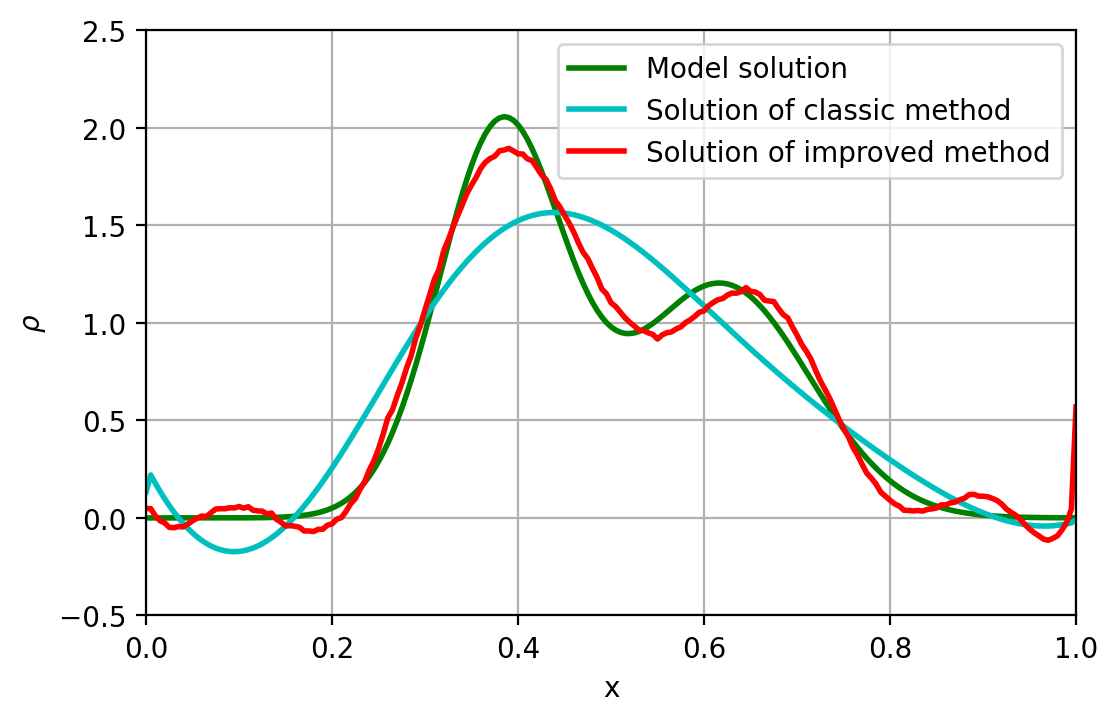

In [7]:

a = 0
b = 1

c = 0.2
d = 1

l_y = 0.2
l_z = 0.8

N  = 200
N_s = 100

x, h = np.linspace(a, b, N+1, retstep=True)
x_s = np.linspace(c, d, N_s)

X_model = model_solution(x)
A = prepare_matrix(x, h, x_s, l_y, l_z)
B = np.dot(A, X_model)

np.random.seed(0)
sigma = 0
delta_B = sigma * np.clip(np.random.normal(size=3*N_s), -3, 3)
delta2 = np.linalg.norm(delta_B)**2
B_delta = np.dot(A, X_model) + delta_B

print(f'delta B = {np.linalg.norm(delta_B) / np.linalg.norm(B):%}')

mu2 = np.linalg.norm(np.dot(A, CG(A, B_delta, x)) - B_delta)**2
mu2_imp = np.linalg.norm(np.dot(A, iCG(A, B_delta, x)) - B_delta)**2


def rho(alpha):
    x_alpha = CG(A, B_delta, x ,alpha)
    return np.linalg.norm(np.dot(A, x_alpha) - B_delta)**2 - delta2 - mu2


def rho_imp(alpha):
    x_alpha_imp = iCG(A, B_delta, x, alpha)
    return np.linalg.norm(np.dot(A, x_alpha_imp) - B_delta)**2 - delta2 - mu2_imp


alpha_0 = init_approx(rho, alpha=1)
alpha_0_imp = init_approx(rho_imp, alpha=1)

alpha_Tikhonov =  newton_PW(alpha_0, A, B_delta, x, delta2, mu2, tol=1e-19)
alpha_Tikhonov_imp = newton_PW(alpha_0_imp, A, B_delta, x, delta2, mu2_imp, improved=True, tol=1e-19)

print(f'alpha = {alpha_Tikhonov}')
print(f'alpha_imp = {alpha_Tikhonov_imp}')

X_inv_Tikhonov  = CG(A, B_delta, x, alpha_Tikhonov)
X_inv_Tikhonov_improved = iCG(A, B_delta, x, alpha_Tikhonov_imp)

print(f'Error using classic method (CG) = {np.linalg.norm(X_inv_Tikhonov - X_model) / np.linalg.norm(X_model):.2%}')
print(f'Error using improved method (iCG) = {np.linalg.norm(X_inv_Tikhonov_improved - X_model) / np.linalg.norm(X_model):.2%}')

plt.axes(xlim=(0, 1), ylim=(-0.5, 2.5))
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.plot(x, X_model, '-g', lw=2, label = 'Model solution')
plt.plot(x, X_inv_Tikhonov, '-c', lw=2, label = 'Solution of classic method')
plt.plot(x, X_inv_Tikhonov_improved, '-r', lw=2, label = 'Solution of improved method')
plt.legend(loc = 1)
plt.grid(True)
plt.show()